In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import cv2

import random
import os
import gc  # garbage collector
import datetime
from tqdm import tqdm
from PIL import Image

from sklearn.preprocessing import StandardScaler as scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

import tensorflow as tf
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf

from time import perf_counter
import seaborn as sns

import fastai
from fastai import *
from fastai.vision import *
from fastai.metrics import error_rate
import torchvision
from torchvision import transforms

def printmd(string):
    # Print with Markdowns
    display(Markdown(string))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/retinopathy.zip

Streaming output truncated to the last 5000 lines.
  inflating: resized_train_cropped/resized_train_cropped/44260_right.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44261_left.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44261_right.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44262_left.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44262_right.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44263_left.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44263_right.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44264_left.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44264_right.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44265_left.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44265_right.jpeg  
  inflating: resized_train_cropped/resized_train_cropped/44267_left.jpeg  
  inflating: resized_train_cropped/resized_

In [ ]:
resized_images = '/content/resized_train/resized_train'
trainLabels = pd.read_csv('/content/trainLabels.csv')
resized_cropped_images = '/content/resized_train_cropped/resized_train_cropped'
trainLabels_cropped = pd.read_csv('/content/trainLabels_cropped.csv')

In [ ]:
trainLabels.head()

,image,level
0,10_left,0
1,10_right,0
2,13_left,0
3,13_right,0
4,15_left,1


In [ ]:
trainLabels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35126 entries, 0 to 35125
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   35126 non-null  object
 1   level   35126 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 549.0+ KB


<ipython-input-8-00dcb5ad1da7>:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  trainLabels.level.plot(kind='hist', figsize=(10, 5), cmap=cm.get_cmap('flag'))


<Axes: ylabel='Frequency'>

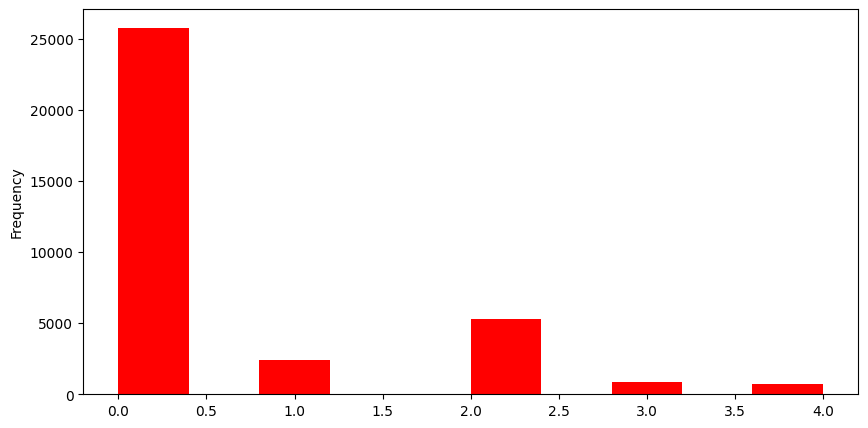

In [ ]:
trainLabels.level.plot(kind='hist', figsize=(10, 5), cmap=cm.get_cmap('flag'))

<ipython-input-9-f3741f814f42>:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  trainLabels_cropped.level.plot(kind='hist', figsize=(10, 5), cmap=cm.get_cmap('ocean'))


<Axes: ylabel='Frequency'>

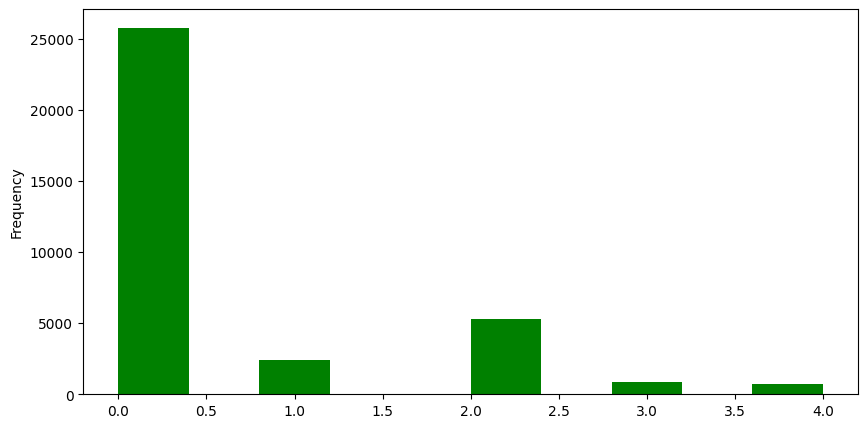

In [ ]:
trainLabels_cropped.level.plot(kind='hist', figsize=(10, 5), cmap=cm.get_cmap('ocean'))

In [ ]:
resized_images_list = (os.listdir(resized_images))
len(resized_images_list)

35126

In [ ]:
plt.figure(figsize=(25, 20))
for i in range(1, 26):
    plt.subplot(5, 5, i)
    img_name = random.choice(resized_images_list)
    img_path = os.path.join(resized_images, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.xlabel(img.shape[1])
    plt.ylabel(img.shape[0])

In [ ]:
resized_train_cropped_list = os.listdir(resized_cropped_images)
len(resized_train_cropped_list)

35108

In [ ]:
plt.figure(figsize=(26, 24))
for i in range(1, 26):
    plt.subplot(5, 5, i)
    img_name = random.choice(resized_train_cropped_list)
    img_path = os.path.join(resized_cropped_images, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.xlabel(img.shape[1])
    plt.ylabel(img.shape[0])

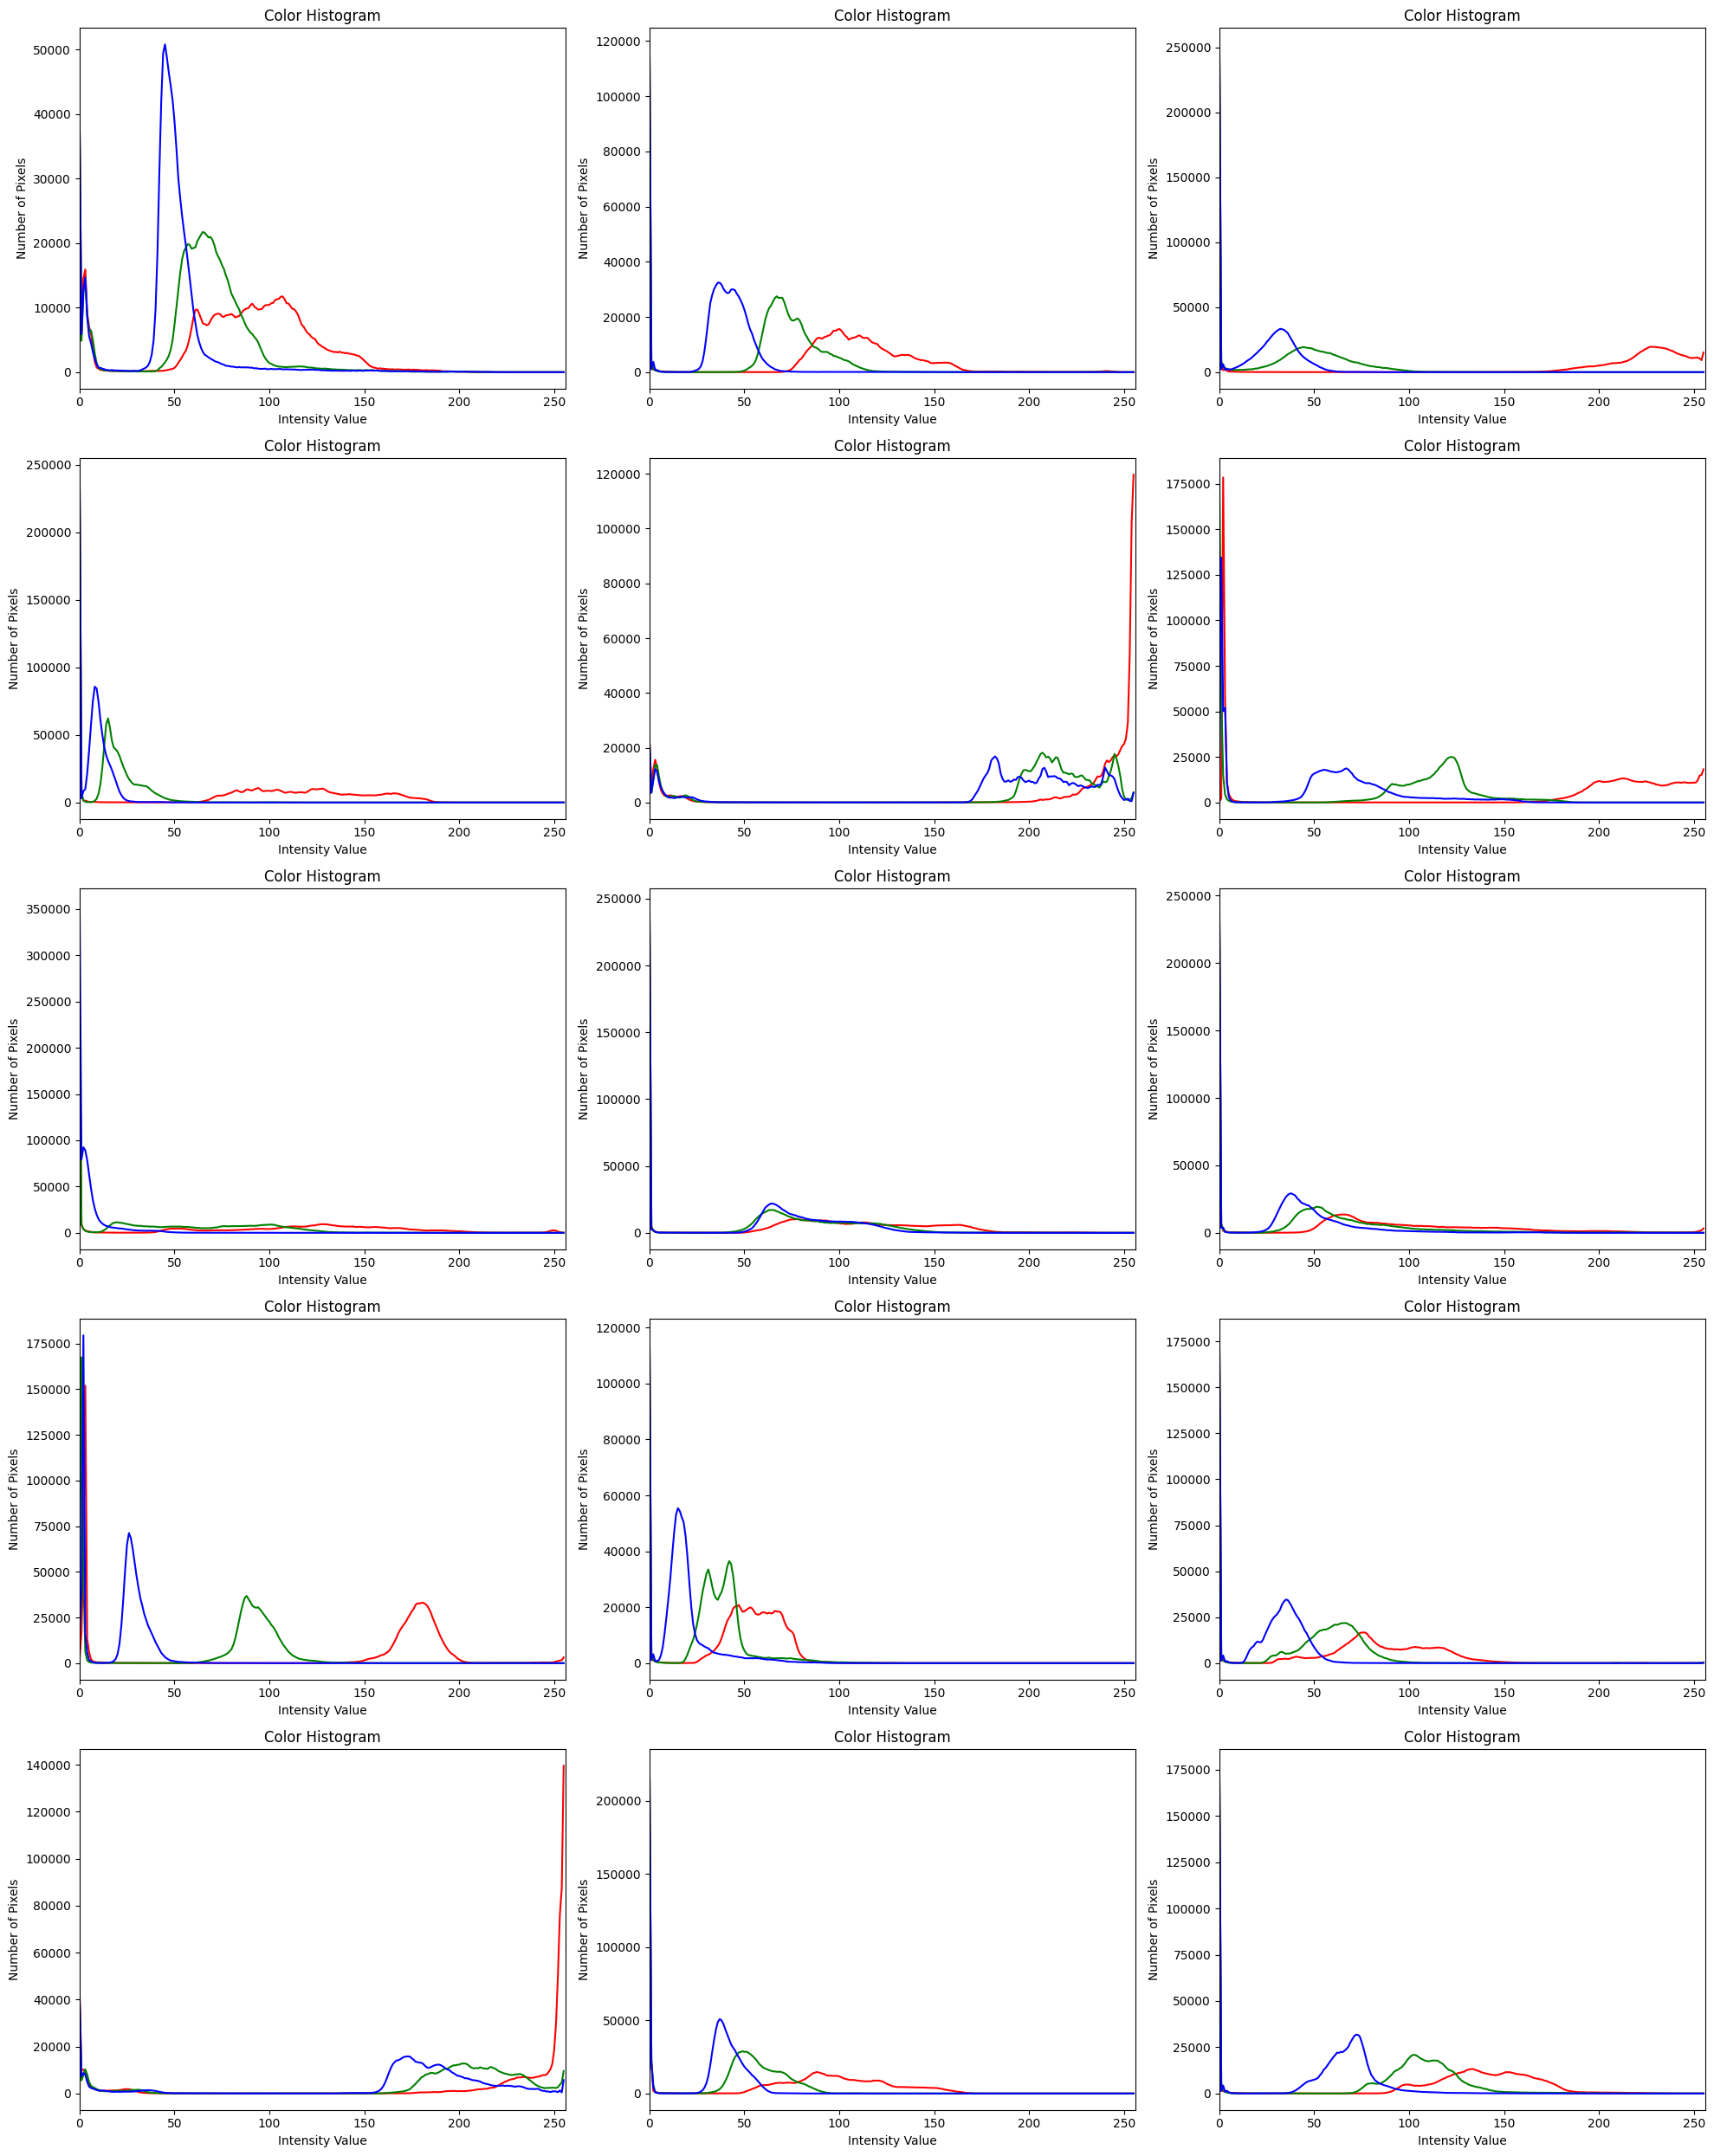

In [ ]:
plt.figure(figsize=(20, 25))
for i in range(1, 16):
    plt.subplot(5, 3, i)
    plt.tight_layout()
    plt.title("Color Histogram")
    plt.xlabel("Intensity Value")
    plt.ylabel("Number of Pixels")
    img_name = random.choice(resized_train_cropped_list)
    img_path = os.path.join(resized_cropped_images, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    channels = cv2.split(img)
    colors = ['r', 'g', 'b']
    for (channel, color) in zip(channels, colors):
        hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
        plt.plot(hist, color=color)
        plt.xlim([0, 256])

In [ ]:
img_width = 100
img_height = 100

def read_img(img_name, resize=False):
    img_path = os.path.join(resized_cropped_images, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if resize:
        img = cv2.resize(img, (img_width, img_height))

    return img

In [ ]:
def ben_graham(img):
    img_ben = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), 10), -4, 128)
    return img_ben

In [ ]:
def hist_equalization(img):
    red, green, blue = cv2.split(img)
    hist_red = cv2.equalizeHist(red)
    hist_green = cv2.equalizeHist(green)
    hist_blue = cv2.equalizeHist(blue)

    img_eq = cv2.merge((hist_red, hist_green, hist_blue))

    return img_eq

In [ ]:
equal_hist_images = resized_train_cropped_list.copy()
len(equal_hist_images)

35108

In [ ]:
plt.figure(figsize=(26, 24))
counter = 0
for img_name in equal_hist_images:
    counter += 1
    plt.subplot(5, 5, counter)
    plt.tight_layout()
    # level_cropped_col is the labels, we've created it above
    plt.title(trainLabels_cropped.level[counter - 1])

    img = read_img(img_name)

    # Applying the Histogram Equaliztion
    img_eq = hist_equalization(img)
    plt.imshow(img_eq)
    plt.xlabel(img_eq.shape[1])
    plt.xlabel(img_eq.shape[0])

    if counter == 25:
        break

In [ ]:
ben_images = resized_train_cropped_list.copy()
len(ben_images)

35108

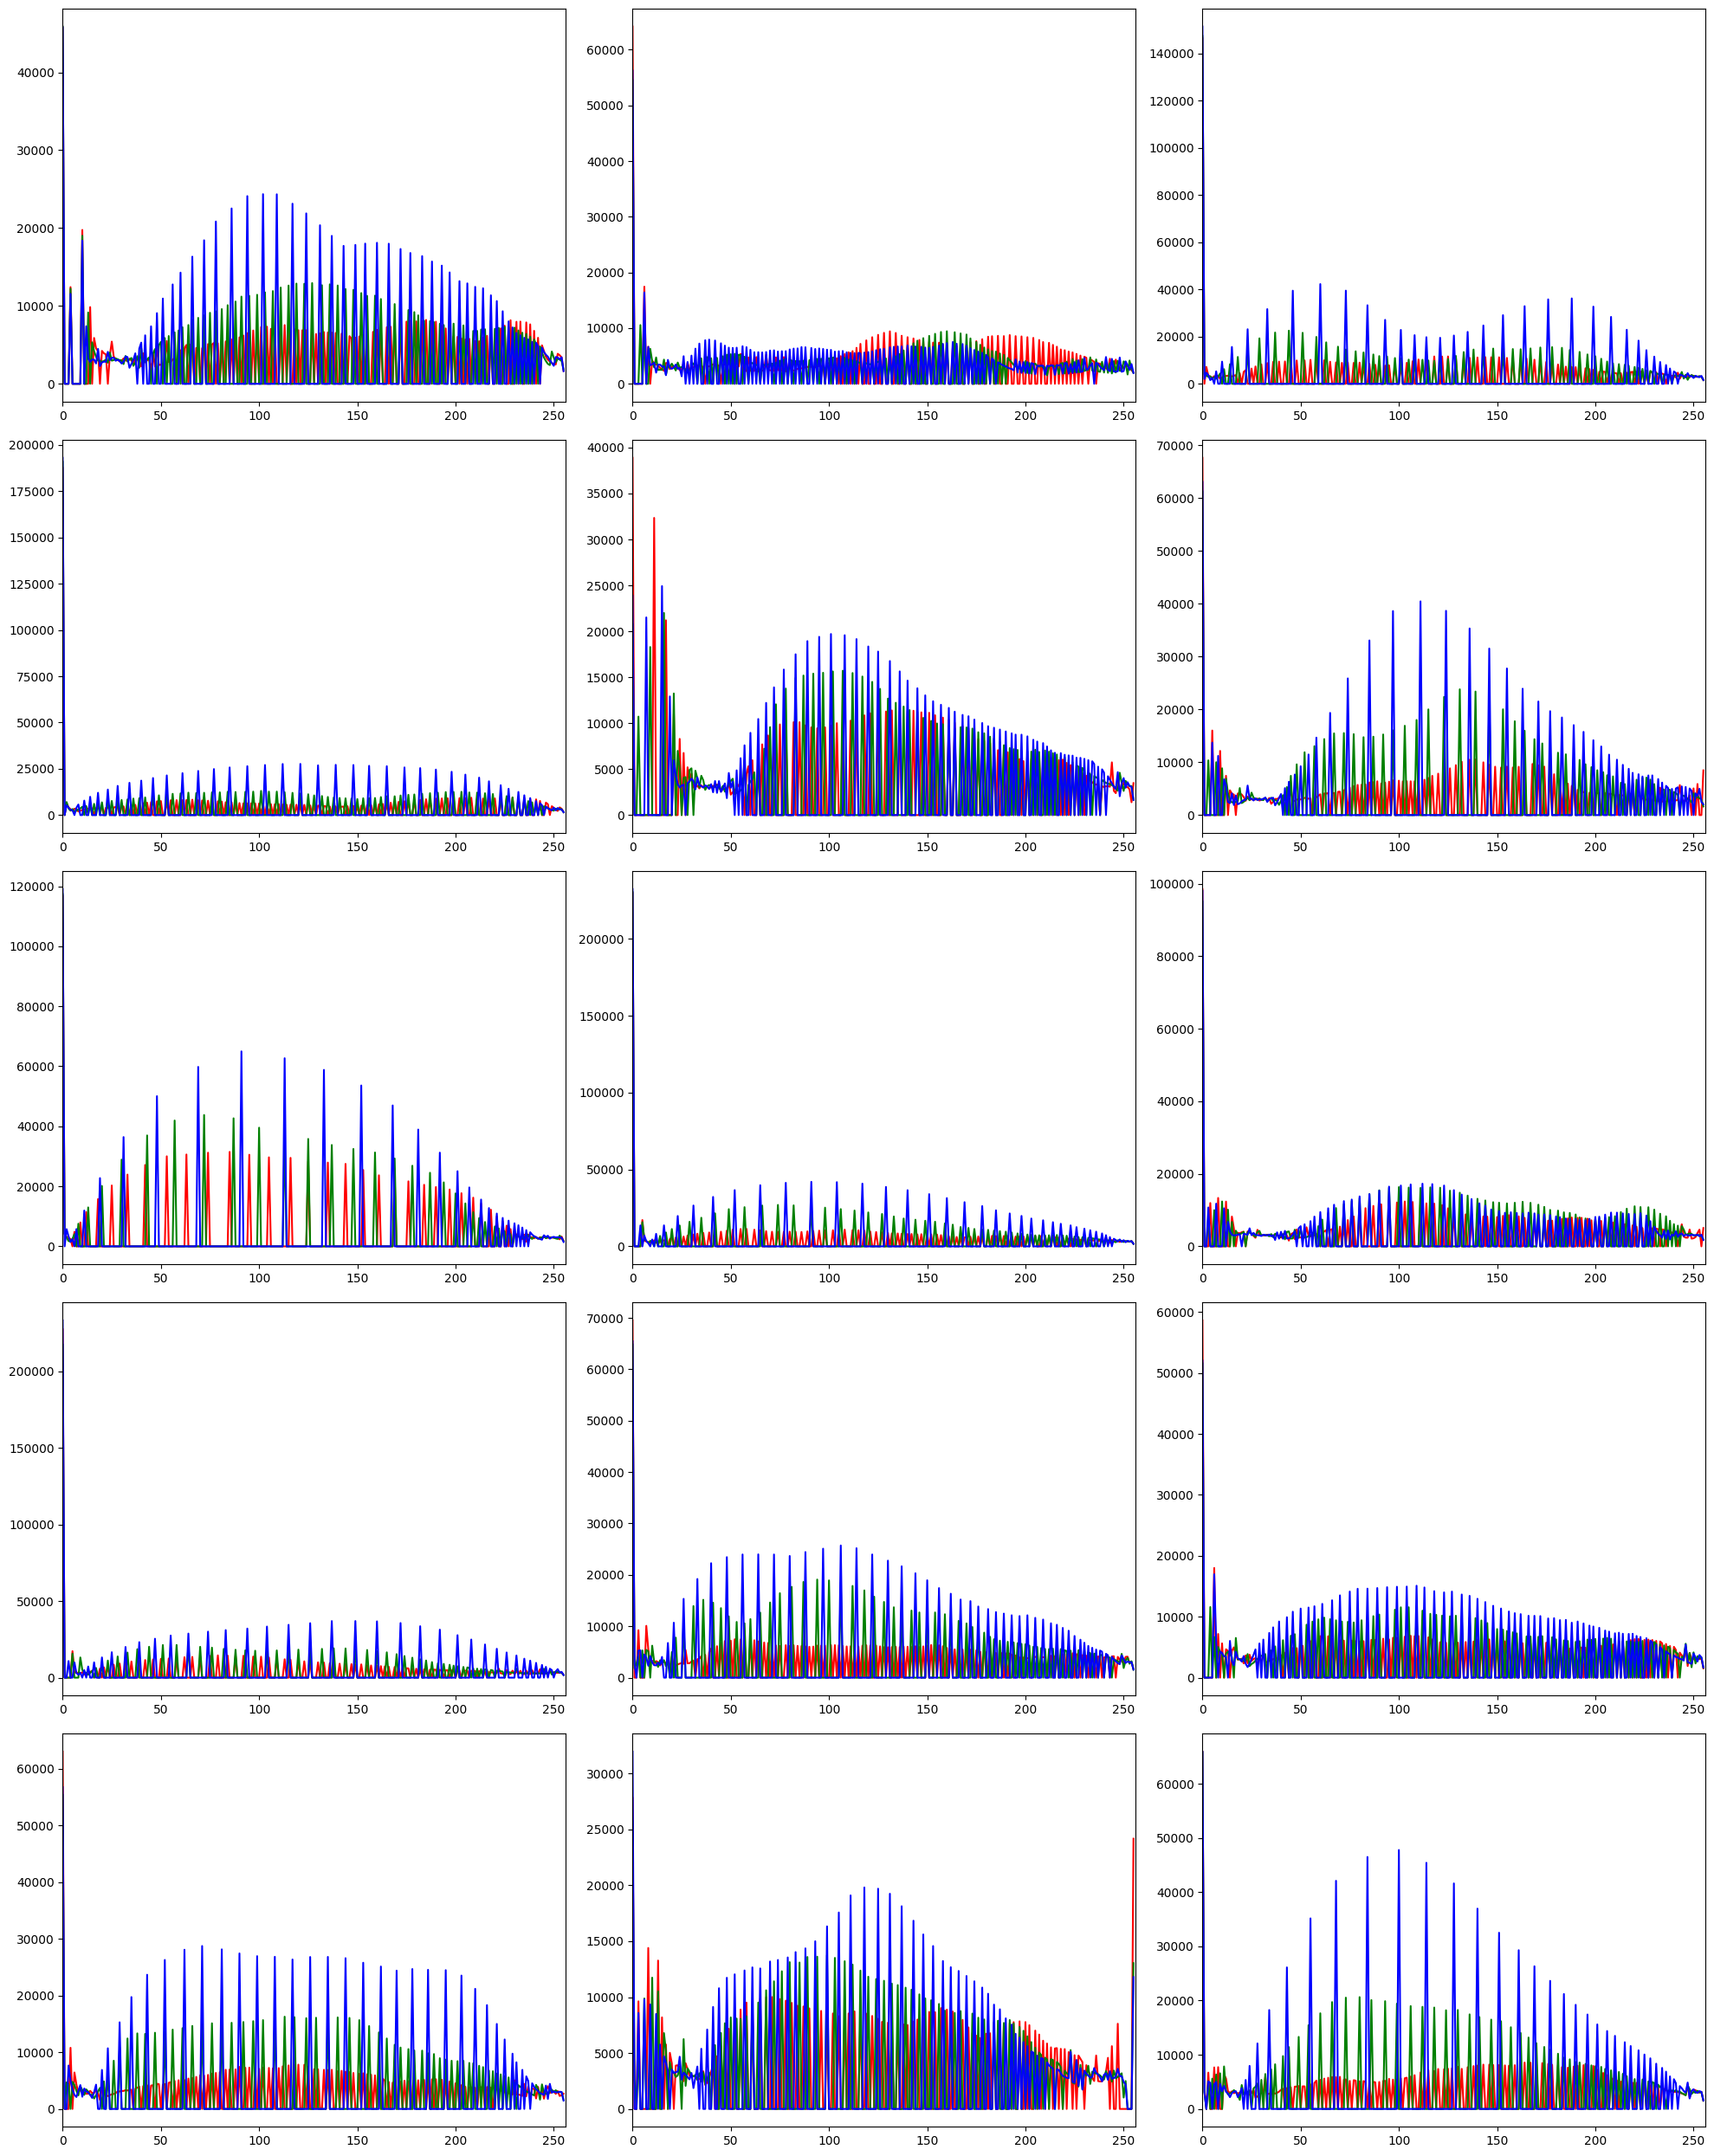

In [ ]:
plt.figure(figsize=(20, 25))
counter = 0
for img_name in equal_hist_images:
    counter += 1
    plt.subplot(5, 3, counter)
    plt.tight_layout()

    img = read_img(img_name)

    # Applying the Histogram Equaliztion
    img_eq = hist_equalization(img)

    channels = cv2.split(img_eq)
    colors = ['r', 'g', 'b']

    for (channel, color) in zip(channels, colors):
        hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
        plt.plot(hist, color=color)
        plt.xlim([0, 256])

    if counter == 15:
        break

In [ ]:
plt.figure(figsize=(26, 24))
counter = 0
for img_name in ben_images:
    counter += 1
    plt.subplot(5, 5, counter)
    plt.tight_layout()
    # level_cropped_col is the lebels list
    plt.title(trainLabels_cropped.level[counter - 1])

    img = read_img(img_name)

    # Applying Ben Graham's Method
    img_ben = ben_graham(img)

    plt.imshow(img_ben)
    plt.xlabel(img_ben.shape[1])
    plt.ylabel(img_ben.shape[0])

    if counter == 25:
        break

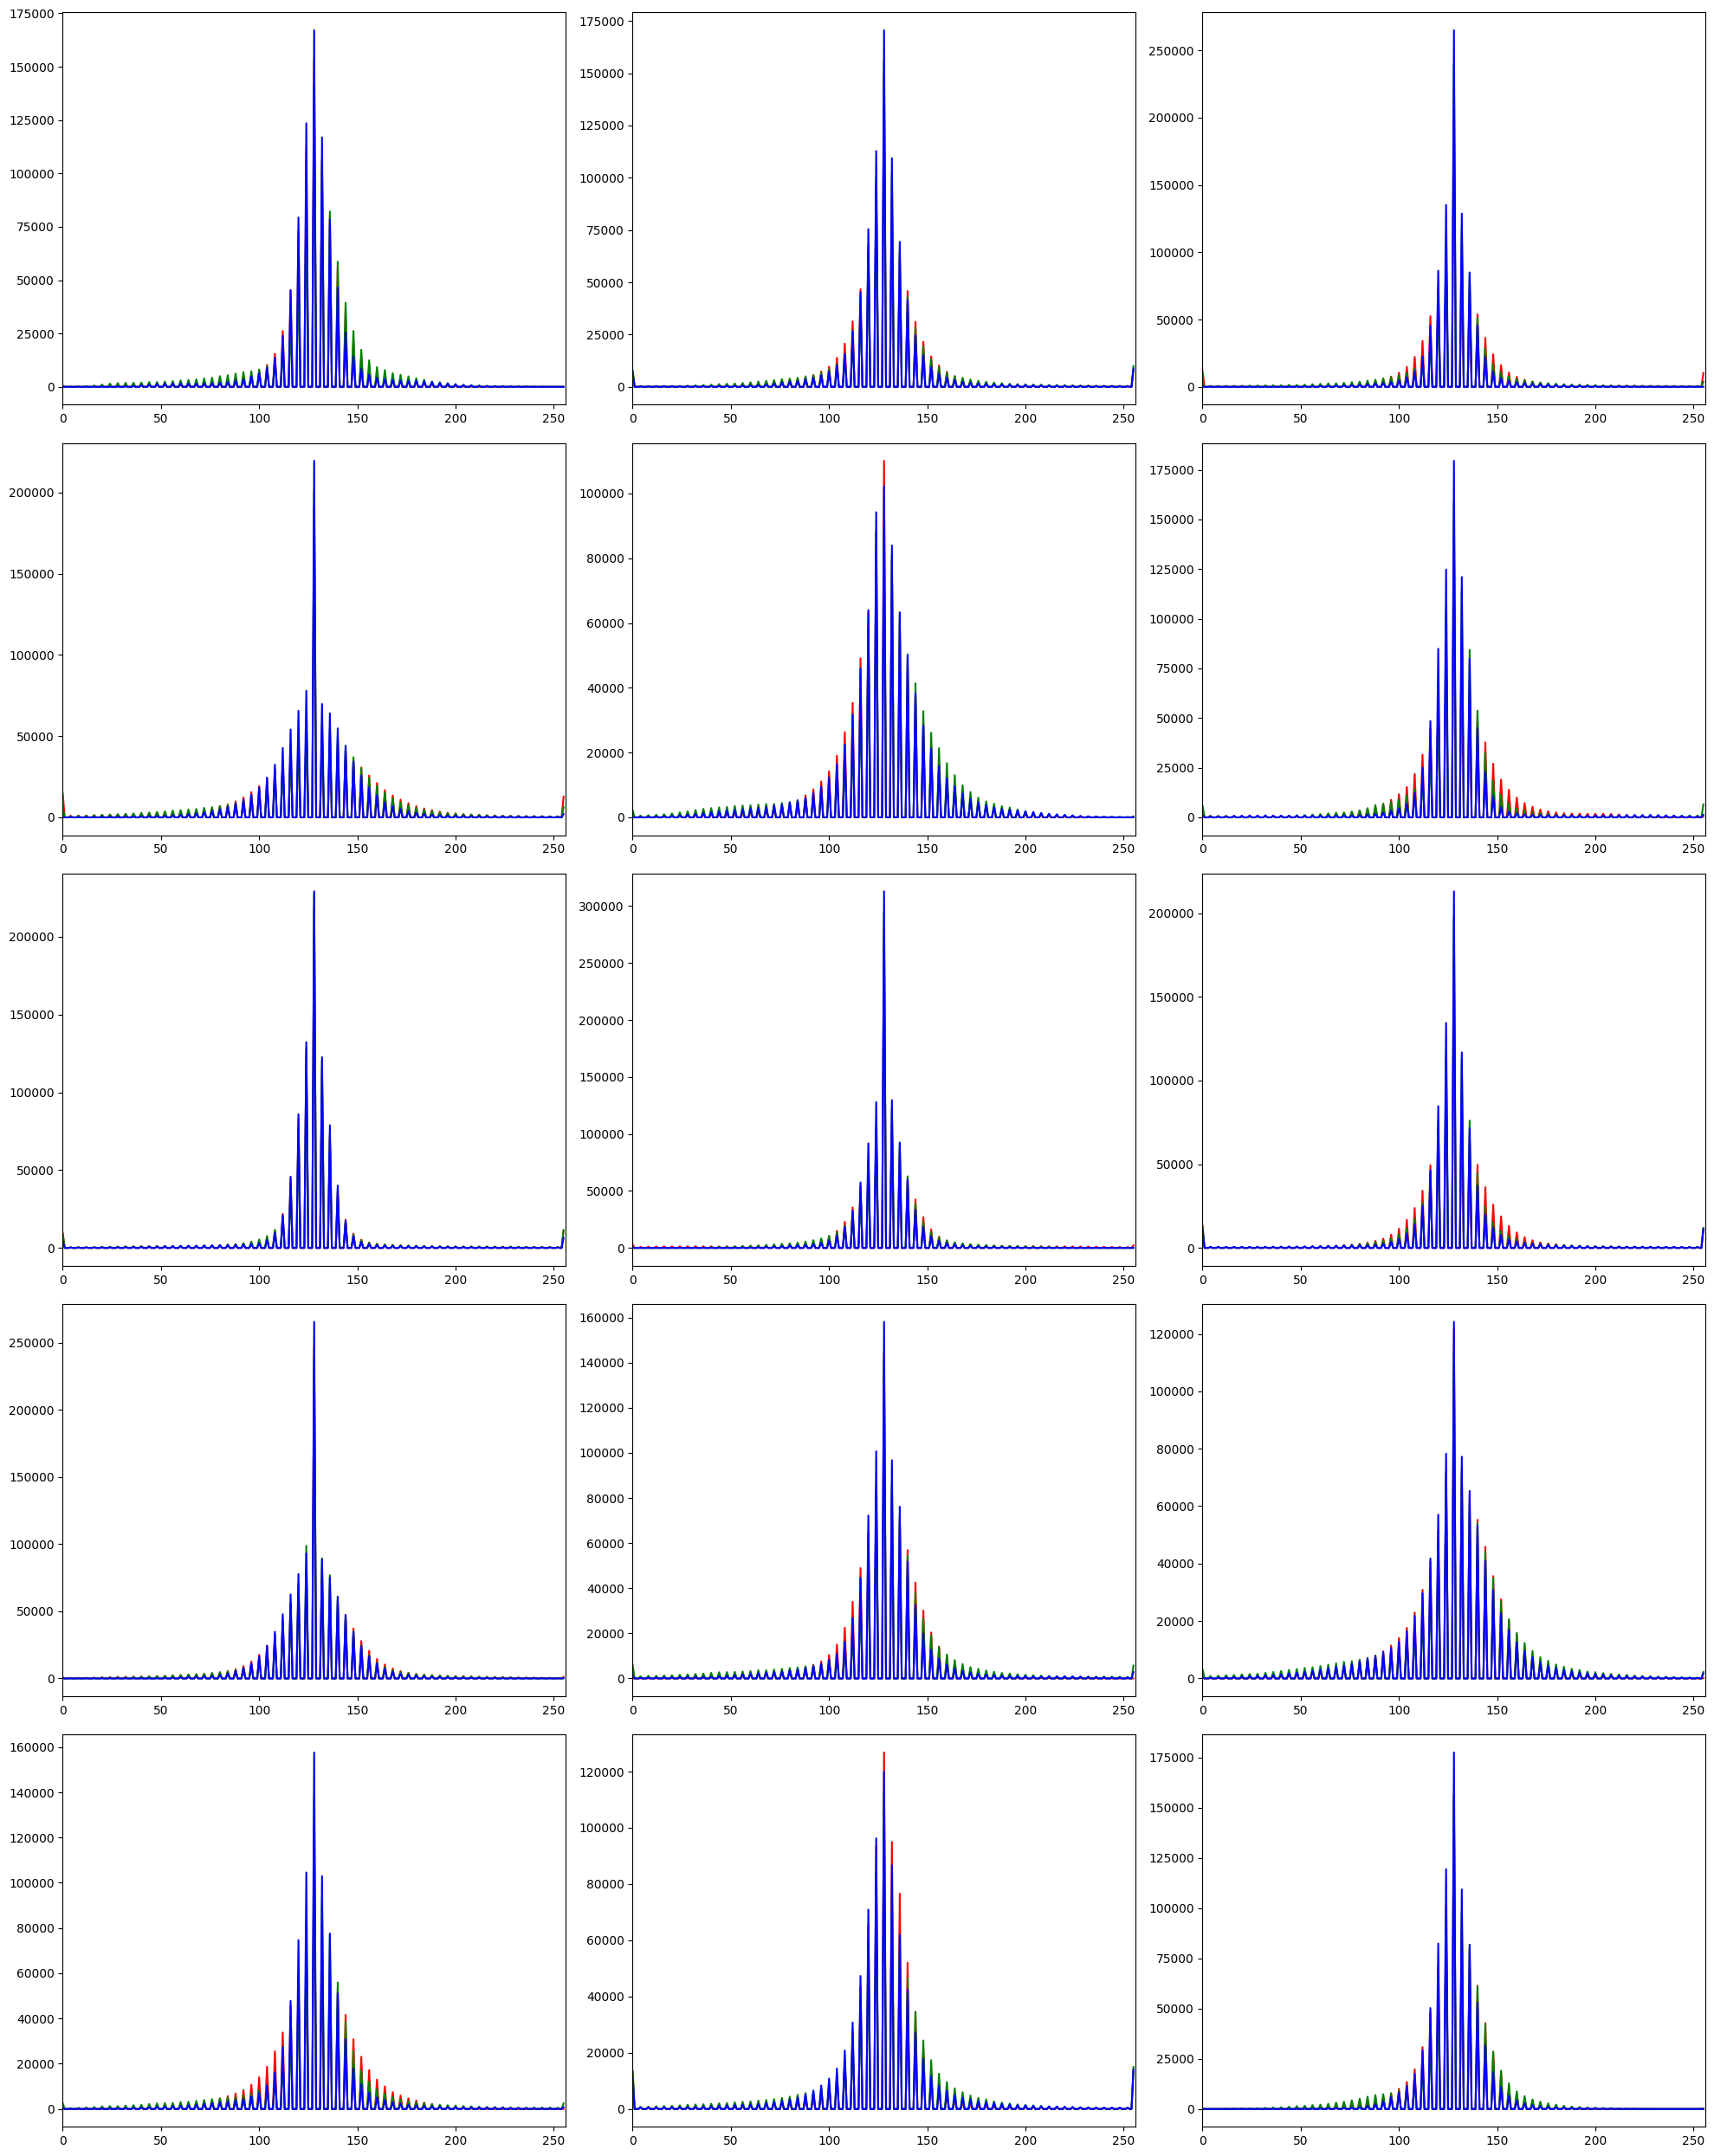

In [ ]:
plt.figure(figsize=(20, 25))
counter = 0
for img_name in equal_hist_images:
    counter += 1
    plt.subplot(5, 3, counter)
    plt.tight_layout()

    img = read_img(img_name)

    # Applying Ben Graham's Method
    img_ben = ben_graham(img)

    channels = cv2.split(img_ben)
    colors = ['r', 'g', 'b']

    for (channel, color) in zip(channels, colors):
        hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
        plt.plot(hist, color=color)
        plt.xlim([0, 256])

    if counter == 15:
        break

In [ ]:
df = pd.read_csv(os.path.join(resized_cropped_images, '/content/trainLabels_cropped.csv'))
df['img_det'] = df['image'].map(lambda x: os.path.join(resized_cropped_images,'/content/resized_train_cropped/resized_train_cropped','{}.jpeg'.format(x)))
df = df.sample(frac=1).reset_index(drop=True) #shuffle dataframe
df.head(10)

,Unnamed: 0.1,Unnamed: 0,image,level,img_det
0,8804,8811,11080_right,0,/content/resized_train_cropped/resized_train_cropped/11080_right.jpeg
1,28036,28052,35517_left,0,/content/resized_train_cropped/resized_train_cropped/35517_left.jpeg
2,30442,30458,38507_left,0,/content/resized_train_cropped/resized_train_cropped/38507_left.jpeg
3,16420,16430,20583_left,0,/content/resized_train_cropped/resized_train_cropped/20583_left.jpeg
4,9602,9609,12103_right,0,/content/resized_train_cropped/resized_train_cropped/12103_right.jpeg
5,803,804,983_left,0,/content/resized_train_cropped/resized_train_cropped/983_left.jpeg
6,5682,5686,7171_left,0,/content/resized_train_cropped/resized_train_cropped/7171_left.jpeg
7,10481,10488,13192_left,0,/content/resized_train_cropped/resized_train_cropped/13192_left.jpeg
8,1324,1326,1650_left,0,/content/resized_train_cropped/resized_train_cropped/1650_left.jpeg
9,32605,32621,41183_right,0,/content/resized_train_cropped/resized_train_cropped/41183_right.jpeg


In [ ]:
len(df)

35108

In [ ]:
df.level

0        0
1        0
2        0
3        0
4        0
        ..
35103    0
35104    0
35105    2
35106    0
35107    0
Name: level, Length: 35108, dtype: int64

In [ ]:
train_df, test_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=1)

In [ ]:
def create_gen():
    # Load the Images with a generator and Data Augmentation
    train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
         preprocessing_function=ben_graham,
         validation_split=0.1
    )

    test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=ben_graham
    )

    train_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='img_det',
        y_col='level',
        target_size=(224, 224),
        class_mode='raw',
        batch_size=32,
        subset='training',
        rotation_range=30, # Uncomment to use data augmentation
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    val_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='img_det',
        y_col='level',
        target_size=(100, 100),
        class_mode='raw',
        batch_size=32,
        shuffle=True,
        seed=0,
        subset='validation',
        rotation_range=30, # Uncomment to use data augmentation
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    test_images = test_generator.flow_from_dataframe(
        dataframe=test_df,
        x_col='img_det',
        y_col='level',
        target_size=(100, 100),
        color_mode='rgb',
        class_mode='raw',
        batch_size=32,
        shuffle=False
    )

    return train_generator,test_generator,train_images,val_images,test_images

In [ ]:
# Create the generators
train_generator,test_generator,train_images,val_images,test_images=create_gen()
print('\n')

Found 22118 validated image filenames.
Found 2457 validated image filenames.
Found 10533 validated image filenames.




In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D

In [ ]:
def get_model(model):
# Load the pretained model
    kwargs =    {'input_shape':(224, 224, 3),
                'include_top':False,
                'weights':'imagenet',
                'pooling':'avg'}

    pretrained_model = model(**kwargs)
    pretrained_model.trainable = False




    x = Dropout(0.2)(pretrained_model.output)
    x = Dropout(0.5)(x)

    x = Dense(2048, activation='relu')(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dropout(0.5)(pretrained_model.output)

    x = Dense(1024, activation='relu')(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.1)(x)

    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.1)(x)
    x = Dense(512, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.2)(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.1)(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.1)(x)


    #x = GlobalAveragePooling2D()(x)
    #x = Dropout(0.1)(x)
    classifier = Dense(5, activation='softmax')(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.1)(x)

    x = Dense(512, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.2)(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.1)(x)

    x = Dense(512, activation='relu')(x)
    classifier = Dropout(0.1)(x)


    inputs = pretrained_model.input
    model = tf.keras.Model(inputs=pretrained_model.inputs, outputs=classifier)

    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
models = {"InceptionV3": {"model":tf.keras.applications.InceptionV3, "perf":0}

}

# Create the generators
train_generator,test_generator,train_images,val_images,test_images=create_gen()
print('\n')

# Fit the models
for name, model in models.items():

    # Get the model
    m = get_model(model['model'])
    models[name]['model'] = m

    start = perf_counter()

    # Fit the model
    history = m.fit(train_images,validation_data=val_images,epochs=5,verbose=1)

Found 22118 validated image filenames.
Found 2457 validated image filenames.
Found 10533 validated image filenames.


27018416/27018416 [==============================] - 2s 0us/step
Epoch 1/5
692/692 [==============================] - 3203s 5s/step - loss: 6.1879 - accuracy: 0.7312 - val_loss: 6.2383 - val_accuracy: 0.7420
Epoch 2/5
692/692 [==============================] - 3269s 5s/step - loss: 6.2398 - accuracy: 0.7363 - val_loss: 6.2383 - val_accuracy: 0.7420
Epoch 3/5
692/692 [==============================] - 3271s 5s/step - loss: 6.2471 - accuracy: 0.7350 - val_loss: 6.2383 - val_accuracy: 0.7420
Epoch 4/5
692/692 [==============================] - 3257s 5s/step - loss: 6.2390 - accuracy: 0.7365 - val_loss: 6.2383 - val_accuracy: 0.7420
Epoch 5/5
692/692 [==============================] - 3231s 5s/step - loss: 6.2383 - accuracy: 0.7366 - val_loss: 6.2383 - val_accuracy: 0.7420


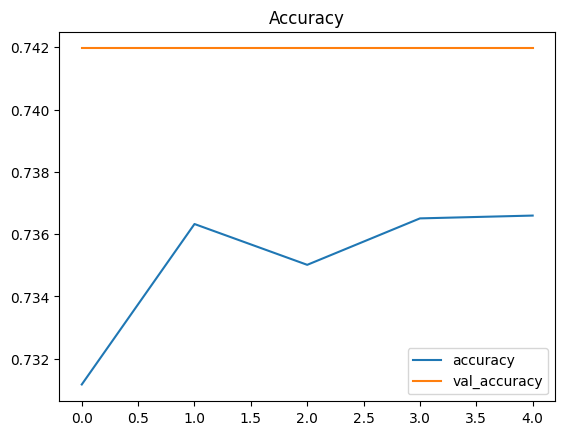

In [ ]:
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

In [ ]:
results = m.evaluate(test_images, verbose=0)

In [ ]:
printmd(" ## Test Loss: {:.5f}".format(results[0]))
printmd("## Accuracy on the test set: {:.2f}%".format(results[1] * 100))

 ## Test Loss: 6.23831

## Accuracy on the test set: 72.98%

In [ ]:
# Predict the level of the test_images
pred = m.predict(test_images)
pred = np.argmax(pred,axis=1)

330/330 [==============================] - 370s 1s/step


In [ ]:
from sklearn.metrics import classification_report
y_test = list(test_df.level)
from sklearn import metrics
print('Accuracy:', np.round(metrics.accuracy_score(y_test,pred),5))
print('Precision:', np.round(metrics.precision_score(y_test, pred, average='weighted'),5))
print('Recall:', np.round(metrics.recall_score(y_test,pred, average='weighted'),5))
print('F1 Score:', np.round(metrics.f1_score(y_test, pred, average='weighted'),5))
print('Cohen Kappa Score:', np.round(metrics.cohen_kappa_score(y_test, pred),5))
print(classification_report(y_test, pred))

Accuracy: 0.7298
Precision: 0.53261
Recall: 0.7298
F1 Score: 0.61581
Cohen Kappa Score: 0.0
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      7687
           1       0.00      0.00      0.00       721
           2       0.00      0.00      0.00      1641
           3       0.00      0.00      0.00       259
           4       0.00      0.00      0.00       225

    accuracy                           0.73     10533
   macro avg       0.15      0.20      0.17     10533
weighted avg       0.53      0.73      0.62     10533



/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: 